<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula09_analisedapoliticamonetaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [ ]:
# Instalar bibliotecas
!pip install ipeadatapy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Importar bibliotecas
import pandas as pd
import seaborn as sns
import ipeadatapy as ipea

# Dados

In [ ]:
# Coleta de dados do Focus Top 5
dados_focus = pd.read_csv(
    filepath_or_buffer = "https://olinda.bcb.gov.br/olinda/servico/Expectativas/" +
    "versao/v1/odata/ExpectativasMercadoAnuais?$filter=Indicador%20eq%20'Selic'%" +
    "20or%20Indicador%20eq%20'IPCA'%20or%20Indicador%20eq%20'PIB%20Total'%20or%20" +
    "Indicador%20eq%20'C%C3%A2mbio'%20and%20baseCalculo%20eq%201&$format=text/csv",
    decimal = ","
)
dados_focus

# Coleta de dados do IPCA 12m
dados_ipca12m = pd.read_csv(
    filepath_or_buffer = "https://olinda.bcb.gov.br/olinda/servico/Expectativas/" +
    "versao/v1/odata/ExpectativasMercadoInflacao12Meses?$filter=Indicador%20eq%2" +
    "0'IPCA'%20and%20Suavizada%20eq%20'S'%20and%20baseCalculo%20eq%200&$format=text/csv",
    decimal = ","
)
dados_ipca12m

,Indicador,IndicadorDetalhe,Data,DataReferencia,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo
0,PIB Total,NaN,2018-01-22,2019,2.8700,2.98,0.4900,1.87,4.00,61.0,0
1,PIB Total,NaN,2018-01-22,2020,2.6800,2.50,0.5000,2.00,4.10,53.0,0
2,PIB Total,NaN,2018-01-22,2021,2.6500,2.50,0.5100,2.00,4.00,48.0,0
3,PIB Total,NaN,2018-01-22,2018,2.6400,2.65,0.5000,0.85,3.77,72.0,0
4,PIB Total,NaN,2018-01-22,2017,0.9900,1.00,0.1200,0.51,1.20,70.0,0
...,...,...,...,...,...,...,...,...,...,...,...
100589,Câmbio,NaN,2022-11-18,2022,5.2882,5.30,0.1341,4.90,5.80,81.0,1
100590,Câmbio,NaN,2022-11-18,2023,5.2714,5.25,0.3149,4.40,7.00,81.0,1
100591,Câmbio,NaN,2022-11-18,2024,5.2317,5.21,0.4018,4.00,7.50,66.0,1
100592,Câmbio,NaN,2022-11-18,2025,5.2674,5.23,0.4748,4.00,8.00,55.0,1


In [ ]:
# Coleta de dados do IPEADATA
dados_ipea = ipea.timeseries("BMF12_SWAPDI36012")
dados_ipea

,YEAR,DAY,MONTH,CODE,RAW DATE,VALUE ((% a.a.))
DATE,,,,,,
1999-09-01,1999,1,9,BMF12_SWAPDI36012,1999-09-01T00:00:00-03:00,25.620000
1999-10-01,1999,1,10,BMF12_SWAPDI36012,1999-10-01T00:00:00-03:00,25.020000
1999-11-01,1999,1,11,BMF12_SWAPDI36012,1999-11-01T00:00:00-03:00,23.790000
1999-12-01,1999,1,12,BMF12_SWAPDI36012,1999-12-01T00:00:00-02:00,22.680000
2000-01-01,2000,1,1,BMF12_SWAPDI36012,2000-01-01T00:00:00-02:00,21.240000
...,...,...,...,...,...,...
2022-06-01,2022,1,6,BMF12_SWAPDI36012,2022-06-01T00:00:00-03:00,13.614286
2022-07-01,2022,1,7,BMF12_SWAPDI36012,2022-07-01T00:00:00-03:00,13.966190
2022-08-01,2022,1,8,BMF12_SWAPDI36012,2022-08-01T00:00:00-03:00,13.521739


In [ ]:
# Tratamento de dados do Focus Top 5
top5 = (
    dados_focus
    .query("baseCalculo == 0")
    .assign(data = lambda x: pd.to_datetime(x.Data).dt.strftime("%Y%m"))
    .groupby(by = ["Indicador", "data", "DataReferencia"], as_index = False)["Mediana"].mean()
    .assign(data = lambda x: pd.to_datetime(x.data, format = "%Y%m"))
)
top5

# Tratamento de dados do IPCA 12m
ipca_12m = (
    dados_ipca12m
    .query("baseCalculo == 0")
    .assign(data = lambda x: pd.to_datetime(x.Data).dt.strftime("%Y%m"))
    .groupby(by = ["data"], as_index = False)["Mediana"].mean()
    .assign(data = lambda x: pd.to_datetime(x.data, format = "%Y%m"))
)
ipca_12m

,Indicador,data,DataReferencia,Mediana
0,IPCA,2000-01-01,2000,6.974762
1,IPCA,2000-01-01,2001,4.000000
2,IPCA,2000-02-01,2000,6.872857
3,IPCA,2000-02-01,2001,4.142857
4,IPCA,2000-03-01,2000,6.555238
...,...,...,...,...
4046,Selic,2022-11-01,2022,13.750000
4047,Selic,2022-11-01,2023,11.270833
4048,Selic,2022-11-01,2024,8.000000
4049,Selic,2022-11-01,2025,8.000000


In [ ]:
# Tratamento de dados do IPEADATA
swaps = (
    dados_ipea
    .reset_index()
    .rename(
        columns = {"DATE": "data", "VALUE ((% a.a.))": "swap"}
        )
    .filter(items = ["data", "swap"], axis = "columns")
)
swaps

,data,swap
0,1999-09-01,25.620000
1,1999-10-01,25.020000
2,1999-11-01,23.790000
3,1999-12-01,22.680000
4,2000-01-01,21.240000
...,...,...
273,2022-06-01,13.614286
274,2022-07-01,13.966190
275,2022-08-01,13.521739
276,2022-09-01,13.440476


In [ ]:
# Cálculo do juro real ex-ante
juro_real = (
    pd.merge(left = ipca_12m, right = swaps, on = "data")
    .assign(juro_real = lambda x: ((1 + x.swap / 100) / (1 + x.Mediana / 100) - 1) * 100)
    .filter(items = ["data", "juro_real"])
)
juro_real

,data,juro_real
0,2001-12-01,15.519375
1,2002-01-01,15.034677
2,2002-02-01,14.587703
3,2002-03-01,13.300516
4,2002-04-01,13.474568
...,...,...
246,2022-06-01,7.355936
247,2022-07-01,8.209966
248,2022-08-01,7.435822
249,2022-09-01,7.705453


In [ ]:
# Cálculo do juro neutro
juro_neutro = (
    top5
    .assign(ano = lambda x: x.data.dt.strftime("%Y").astype(int))
    .query("Indicador == ['IPCA', 'Selic'] and DataReferencia == ano + 3")
    .pivot(index = ["data", "DataReferencia"], columns = "Indicador", values = "Mediana")
    .assign(neutro = lambda x: ((1 + x.Selic / 100) / (1 + x.IPCA / 100) - 1) * 100)
    .reset_index()
    .filter(items = ["data", "neutro"])
)
juro_neutro

Indicador,data,neutro
0,2000-08-01,7.578813
1,2000-09-01,8.206311
2,2000-10-01,8.125679
3,2000-11-01,8.239726
4,2000-12-01,8.366796
...,...,...
253,2022-07-01,4.368729
254,2022-08-01,4.368919
255,2022-09-01,4.432501
256,2022-10-01,4.599515


# Visualização de dados

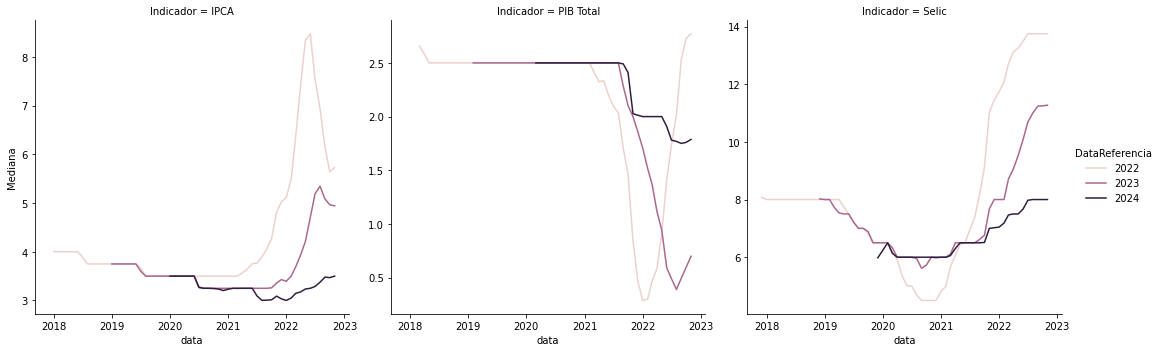

In [ ]:
# Gráfico de linha variáveis do Focus Top 5
sns.relplot(
    data = top5.query("DataReferencia >= 2022 and DataReferencia <= 2024"),
    x = "data",
    y = "Mediana",
    hue = "DataReferencia",
    col = "Indicador",
    kind = "line",
    facet_kws = dict(sharey = False)
)

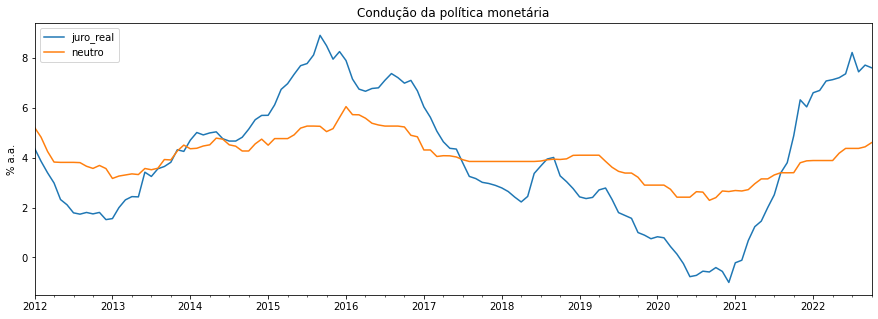

In [ ]:
# Gráfico de linha da Condução da política monetária
(
    pd.merge(left = juro_real, right = juro_neutro, on = "data")
    .query("data >= '2012-01-01'")
    .set_index("data")
    .plot(
        figsize = (15,5),
        title = "Condução da política monetária",
        xlabel = "",
        ylabel = "% a.a."
        )

)